# FraudLens v2.0
## AI-Assisted Financial Statement Fraud Detection Pipeline

### What's New in v2.0
- Real CSV file upload support
- Data validation and quality checks
- Visual charts and graphs
- PDF investigation report export
- Ready for real financial statement data

### How to Use FraudLens
1. Prepare your CSV file using the FraudLens template format
2. Update the file path in the loader cell
3. Run All cells from top to bottom
4. Review the risk classifications and charts
5. Export the PDF investigation report

### Author
**Name:** Theophilus Abayayateye
**Project:** FraudLens v2.0
**Field:** Forensic Accounting & Financial Crime Investigation

In [1]:
# =============================================================
# FRAUDLENS v2.0 - Library Imports
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8')

print("=" * 40)
print("FraudLens v2.0 libraries loaded")
print("=" * 40)

FraudLens v2.0 libraries loaded


## Step 1: Load and Validate Data

Update the file path below to point to your CSV file.
Use the FraudLens template format found in the data folder.

In [2]:
# =============================================================
# FRAUDLENS v2.0 - CSV Loader and Validator
# =============================================================
# UPDATE THIS PATH to point to your CSV file
FILE_PATH = 'D:/FraudLens/data/fraudlens_template.csv'
# =============================================================

REQUIRED_COLUMNS = [
    'company_id', 'sales_t', 'sales_t1',
    'receivables_t', 'receivables_t1',
    'COGS_t', 'COGS_t1',
    'total_assets_t', 'total_assets_t1',
    'PPE_t', 'PPE_t1',
    'net_income_t', 'total_debt_t', 'cash_flow_ops_t'
]

def load_and_validate(filepath):
    print(f"Loading: {filepath}")
    df = pd.read_csv(filepath)
    print(f"Rows loaded: {len(df)}")
    
    # Check for missing columns
    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        print(f"ERROR - Missing columns: {missing}")
        return None
    
    # Handle missing values
    missing_values = df[REQUIRED_COLUMNS].isnull().sum()
    if missing_values.any():
        print("WARNING - Missing values found:")
        print(missing_values[missing_values > 0])
        print("Filling with column median...")
        df[REQUIRED_COLUMNS] = df[REQUIRED_COLUMNS].fillna(
            df[REQUIRED_COLUMNS].median()
        )
    
    print("Validation passed!")
    return df

# Load data
data = load_and_validate(FILE_PATH)

# Show summary
print()
print("=" * 45)
print("         FRAUDLENS - DATA SUMMARY")
print("=" * 45)
print(f"  Companies loaded  : {len(data)}")
print(f"  Columns available : {len(data.columns)}")
if 'company_name' in data.columns:
    print(f"  Companies         : {', '.join(data['company_name'].tolist())}")
print("=" * 45)

Loading: D:/FraudLens/data/fraudlens_template.csv
Rows loaded: 3
Validation passed!

         FRAUDLENS - DATA SUMMARY
  Companies loaded  : 3
  Columns available : 15
  Companies         : Company A, Company B, Company C


## Step 2: Calculate Beneish M-Score

In [3]:
# =============================================================
# FRAUDLENS v2.0 - Beneish M-Score Calculation
# =============================================================

def calculate_beneish(df):
    df = df.copy()
    
    # 8 Beneish Indices
    df['DSRI'] = (df['receivables_t'] / df['sales_t']) / \
                 (df['receivables_t1'] / df['sales_t1'])
    
    df['GMI']  = ((df['sales_t1'] - df['COGS_t1']) / df['sales_t1']) / \
                 ((df['sales_t'] - df['COGS_t']) / df['sales_t'])
    
    df['AQI']  = (1 - (df['PPE_t'] + df['receivables_t']) / df['total_assets_t']) / \
                 (1 - (df['PPE_t1'] + df['receivables_t1']) / df['total_assets_t1'])
    
    df['SGI']  = df['sales_t'] / df['sales_t1']
    
    df['DEPI'] = (df['PPE_t1'] / (df['PPE_t1'] + df['PPE_t'])) / \
                 (df['PPE_t'] / (df['PPE_t'] + df['PPE_t1']))
    
    df['SGA_t']  = df['sales_t'] * 0.10
    df['SGA_t1'] = df['sales_t1'] * 0.10
    df['SGAI']   = (df['SGA_t'] / df['sales_t']) / \
                   (df['SGA_t1'] / df['sales_t1'])
    
    df['LVGI'] = (df['total_debt_t'] / df['total_assets_t']) / \
                 (df['total_debt_t'] / df['total_assets_t1'])
    
    df['TATA'] = (df['net_income_t'] - df['cash_flow_ops_t']) / \
                  df['total_assets_t']
    
    # M-Score
    df['M_Score'] = (-4.84
        + (0.920 * df['DSRI'])
        + (0.528 * df['GMI'])
        + (0.404 * df['AQI'])
        + (0.892 * df['SGI'])
        + (0.115 * df['DEPI'])
        - (0.172 * df['SGAI'])
        + (4.679 * df['TATA'])
        - (0.327 * df['LVGI']))
    
    df['beneish_flag'] = (df['M_Score'] > -2.22).astype(int)
    
    return df

data = calculate_beneish(data)

print(data[['company_id', 'M_Score', 'beneish_flag']].to_string(index=False))
print()
print(f"Companies flagged by Beneish: {data['beneish_flag'].sum()} of {len(data)}")

 company_id  M_Score  beneish_flag
          1  -2.2124             1
          2  -2.3290             0
          3  -2.3026             0

Companies flagged by Beneish: 1 of 3


## Step 3: Anomaly Detection and Risk Scoring

In [4]:
# =============================================================
# FRAUDLENS v2.0 - Anomaly Detection and Risk Scoring
# =============================================================

FEATURES = ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'LVGI', 'TATA']

def detect_and_score(df):
    df = df.copy()
    
    # Scale features
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[FEATURES])
    
    # Z-Score detection
    z_scores = np.abs(scaled)
    df['z_score_flag'] = (z_scores > 2).any(axis=1).astype(int)
    
    # Isolation Forest
    iso = IsolationForest(contamination=0.2, random_state=42)
    df['iso_flag'] = (iso.fit_predict(scaled) == -1).astype(int)
    
    # Risk Score using M-Score and flags
    # Normalize M-Score to 0-1 range for scoring
    m_min, m_max = -6, 35
    df['risk_score'] = (df['M_Score'] - m_min) / (m_max - m_min)
    df['risk_score'] = df['risk_score'].clip(0, 1)
    
    # Boost score if anomaly flags triggered
    df['risk_score'] = df['risk_score'] + (df['z_score_flag'] * 0.1)
    df['risk_score'] = df['risk_score'] + (df['iso_flag'] * 0.1)
    df['risk_score'] = df['risk_score'].clip(0, 1)
    
    # Classify risk
    def classify(score):
        if score >= 0.7:
            return 'High Risk'
        elif score >= 0.4:
            return 'Medium Risk'
        else:
            return 'Low Risk'
    
    df['risk_classification'] = df['risk_score'].apply(classify)
    df['fraud_probability']   = (df['risk_score'] * 100).round(1)
    
    return df

data = detect_and_score(data)

print(data[['company_id', 'M_Score', 'fraud_probability', 
            'risk_classification']].to_string(index=False))

 company_id  M_Score  fraud_probability risk_classification
          1  -2.2124             9.2000            Low Risk
          2  -2.3290            19.0000            Low Risk
          3  -2.3026             9.0000            Low Risk


## Step 4: Visualizations

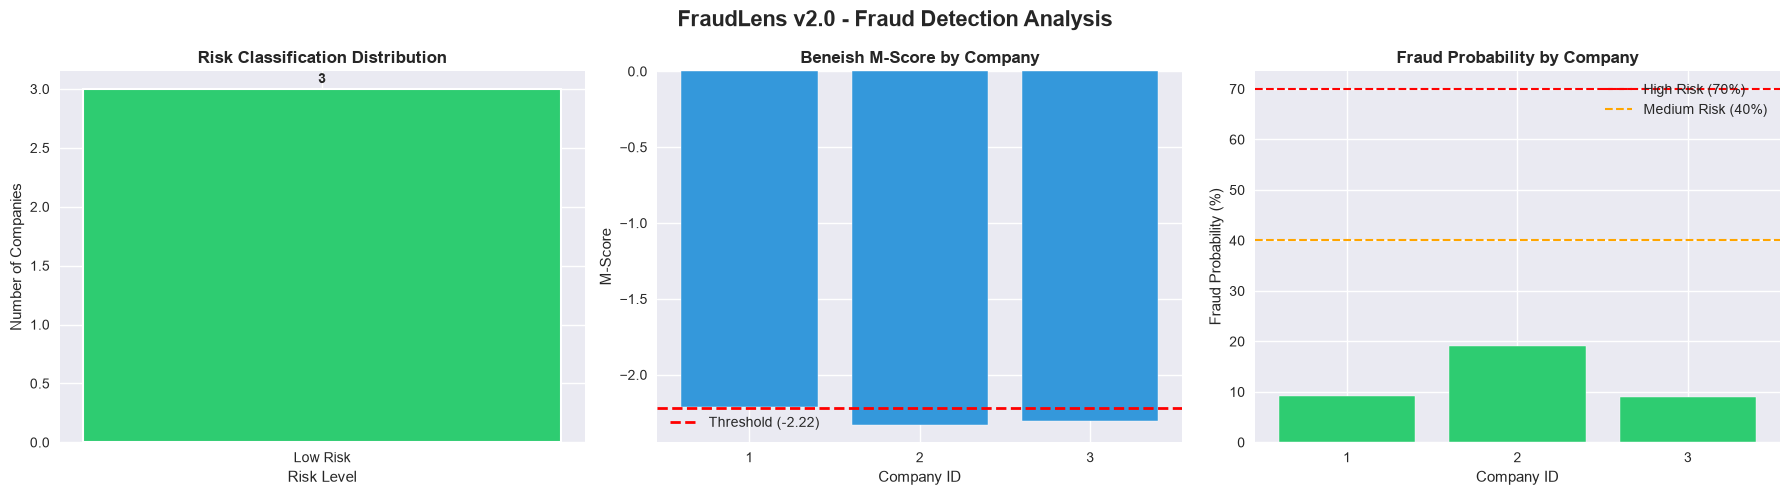

Charts saved to output folder


In [5]:
# =============================================================
# FRAUDLENS v2.0 - Visualizations
# =============================================================

def plot_results(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('FraudLens v2.0 - Fraud Detection Analysis',
                 fontsize=16, fontweight='bold')

    # --- Chart 1: Risk Distribution ---
    risk_counts = df['risk_classification'].value_counts()
    color_map = {
        'High Risk'  : '#e74c3c',
        'Medium Risk': '#f39c12',
        'Low Risk'   : '#2ecc71'
    }
    bar_colors = [color_map.get(r, '#95a5a6') for r in risk_counts.index]
    axes[0].bar(risk_counts.index, risk_counts.values,
                color=bar_colors, edgecolor='white', linewidth=1.5)
    axes[0].set_title('Risk Classification Distribution', fontweight='bold')
    axes[0].set_xlabel('Risk Level')
    axes[0].set_ylabel('Number of Companies')
    for i, v in enumerate(risk_counts.values):
        axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    # --- Chart 2: M-Score Distribution ---
    axes[1].bar(df['company_id'].astype(str), df['M_Score'],
                color='#3498db', edgecolor='white')
    axes[1].axhline(y=-2.22, color='red', linestyle='--',
                    linewidth=2, label='Threshold (-2.22)')
    axes[1].set_title('Beneish M-Score by Company', fontweight='bold')
    axes[1].set_xlabel('Company ID')
    axes[1].set_ylabel('M-Score')
    axes[1].legend()

    # --- Chart 3: Fraud Probability ---
    bar_colors2 = [
        '#e74c3c' if p >= 70 else '#f39c12' if p >= 40 else '#2ecc71'
        for p in df['fraud_probability']
    ]
    axes[2].bar(df['company_id'].astype(str), df['fraud_probability'],
                color=bar_colors2, edgecolor='white')
    axes[2].axhline(y=70, color='red', linestyle='--', linewidth=1.5, label='High Risk (70%)')
    axes[2].axhline(y=40, color='orange', linestyle='--', linewidth=1.5, label='Medium Risk (40%)')
    axes[2].set_title('Fraud Probability by Company', fontweight='bold')
    axes[2].set_xlabel('Company ID')
    axes[2].set_ylabel('Fraud Probability (%)')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('D:/FraudLens/output/fraudlens_v2_charts.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Charts saved to output folder")

plot_results(data)

## Step 5: PDF Investigation Report Export

FraudLens generates a professional PDF report summarising
the fraud risk findings for all analysed companies.

In [7]:
# =============================================================
# FRAUDLENS v2.0 - Interpretation Engine
# =============================================================

def interpret_company(row):
    """
    Generates a plain English interpretation for each company
    based on their Beneish indices and risk score.
    """
    name = row.get('company_name', f"Company {int(row['company_id'])}")
    findings = []
    
    # DSRI interpretation
    if row['DSRI'] > 1.5:
        findings.append(
            f"Receivables grew disproportionately faster than sales "
            f"(DSRI: {row['DSRI']:.2f}), suggesting possible revenue inflation."
        )
    elif row['DSRI'] > 1.1:
        findings.append(
            f"Mild increase in receivables relative to sales "
            f"(DSRI: {row['DSRI']:.2f}). Monitor for continued growth."
        )

    # GMI interpretation
    if row['GMI'] > 1.2:
        findings.append(
            f"Gross margin has deteriorated significantly "
            f"(GMI: {row['GMI']:.2f}), indicating declining profitability."
        )
    elif row['GMI'] < 0:
        findings.append(
            f"Gross margin turned negative (GMI: {row['GMI']:.2f}), "
            f"which is a serious red flag."
        )

    # SGI interpretation
    if row['SGI'] < 0.8:
        findings.append(
            f"Sales declined sharply (SGI: {row['SGI']:.2f}) while "
            f"other indicators worsened — a suspicious combination."
        )
    elif row['SGI'] > 1.6:
        findings.append(
            f"Unusually high sales growth (SGI: {row['SGI']:.2f}). "
            f"High-growth companies are statistically more likely to manipulate."
        )

    # TATA interpretation
    if row['TATA'] > 0.1:
        findings.append(
            f"Reported income significantly exceeds operating cash flow "
            f"(TATA: {row['TATA']:.4f}), suggesting possible accruals manipulation."
        )
    elif row['TATA'] < -0.1:
        findings.append(
            f"Cash flow exceeds reported income (TATA: {row['TATA']:.4f}), "
            f"which is generally a healthy sign."
        )

    # LVGI interpretation
    if row['LVGI'] > 1.2:
        findings.append(
            f"Debt levels increased relative to assets "
            f"(LVGI: {row['LVGI']:.2f}), indicating rising financial risk."
        )

    # M-Score interpretation
    if row['M_Score'] > -2.22:
        findings.append(
            f"Beneish M-Score of {row['M_Score']:.4f} exceeds the -2.22 threshold "
            f"— the model flags this company as a likely manipulator."
        )
    else:
        findings.append(
            f"Beneish M-Score of {row['M_Score']:.4f} is below the -2.22 threshold "
            f"— no manipulation indicated by the Beneish model."
        )

    # Overall verdict
    risk = row['risk_classification']
    prob = row['fraud_probability']

    if risk == 'High Risk':
        verdict = (f"{name} is classified as HIGH RISK with a fraud probability of {prob}%. "
                   f"Immediate further investigation is recommended.")
    elif risk == 'Medium Risk':
        verdict = (f"{name} is classified as MEDIUM RISK with a fraud probability of {prob}%. "
                   f"Enhanced monitoring and follow-up review is advised.")
    else:
        verdict = (f"{name} is classified as LOW RISK with a fraud probability of {prob}%. "
                   f"No immediate action required based on current indicators.")

    return {
        'name'    : name,
        'verdict' : verdict,
        'findings': findings
    }

# Generate interpretations for all companies
interpretations = [interpret_company(row) for _, row in data.iterrows()]

# Preview one interpretation
for item in interpretations:
    print(f"Company: {item['name']}")
    print(f"Verdict: {item['verdict']}")
    print("Findings:")
    for f in item['findings']:
        print(f"  - {f}")
    print()

Company: Company A
Verdict: Company A is classified as LOW RISK with a fraud probability of 9.2%. No immediate action required based on current indicators.
Findings:
  - Beneish M-Score of -2.2124 exceeds the -2.22 threshold — the model flags this company as a likely manipulator.

Company: Company B
Verdict: Company B is classified as LOW RISK with a fraud probability of 19.0%. No immediate action required based on current indicators.
Findings:
  - Mild increase in receivables relative to sales (DSRI: 1.25). Monitor for continued growth.
  - Beneish M-Score of -2.3290 is below the -2.22 threshold — no manipulation indicated by the Beneish model.

Company: Company C
Verdict: Company C is classified as LOW RISK with a fraud probability of 9.0%. No immediate action required based on current indicators.
Findings:
  - Beneish M-Score of -2.3026 is below the -2.22 threshold — no manipulation indicated by the Beneish model.



In [9]:
# =============================================================
# FRAUDLENS v2.0 - PDF Report Generator
# =============================================================

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.units import inch
from datetime import datetime

def generate_pdf_report(df, interpretations, 
                        output_path='D:/FraudLens/output/FraudLens_Report.pdf'):
    
    doc = SimpleDocTemplate(output_path, pagesize=A4)
    styles = getSampleStyleSheet()
    story = []
    
    # --- Title ---
    title_style = ParagraphStyle('Title', fontSize=20, spaceAfter=10,
                                  textColor=colors.HexColor('#2c3e50'),
                                  fontName='Helvetica-Bold')
    subtitle_style = ParagraphStyle('Subtitle', fontSize=12, spaceAfter=20,
                                     textColor=colors.HexColor('#7f8c8d'))
    finding_style = ParagraphStyle('Finding', fontSize=9, spaceAfter=4,
                                    leftIndent=20,
                                    textColor=colors.HexColor('#2c3e50'))
    verdict_style = ParagraphStyle('Verdict', fontSize=10, spaceAfter=6,
                                    fontName='Helvetica-Bold',
                                    textColor=colors.HexColor('#2c3e50'))

    story.append(Paragraph("FraudLens v2.0", title_style))
    story.append(Paragraph("AI-Assisted Financial Statement Fraud Detection Report", 
                            subtitle_style))
    story.append(Paragraph(
        f"Generated: {datetime.now().strftime('%d %B %Y, %H:%M')}", subtitle_style))
    story.append(Spacer(1, 0.2 * inch))
    
    # --- Executive Summary ---
    story.append(Paragraph("Executive Summary", styles['Heading2']))
    total = len(df)
    high  = len(df[df['risk_classification'] == 'High Risk'])
    med   = len(df[df['risk_classification'] == 'Medium Risk'])
    low   = len(df[df['risk_classification'] == 'Low Risk'])
    
    summary_text = f"""
    FraudLens analysed <b>{total}</b> companies using the Beneish M-Score model,
    Z-score anomaly detection, and Isolation Forest machine learning.<br/><br/>
    <b>High Risk:</b> {high} companies &nbsp;&nbsp;
    <b>Medium Risk:</b> {med} companies &nbsp;&nbsp;
    <b>Low Risk:</b> {low} companies
    """
    story.append(Paragraph(summary_text, styles['Normal']))
    story.append(Spacer(1, 0.2 * inch))
    
    # --- Results Table ---
    story.append(Paragraph("Company Risk Classifications", styles['Heading2']))
    table_data = [['Company ID', 'Company Name', 'M-Score',
                   'Fraud Probability', 'Risk Classification']]
    for _, row in df.iterrows():
        name = row.get('company_name', f"Company {int(row['company_id'])}")
        table_data.append([
            str(int(row['company_id'])),
            str(name),
            f"{row['M_Score']:.4f}",
            f"{row['fraud_probability']:.1f}%",
            row['risk_classification']
        ])
    
    table = Table(table_data, 
                  colWidths=[1*inch, 1.8*inch, 1.2*inch, 1.5*inch, 1.5*inch])
    table.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#2c3e50')),
        ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
        ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
        ('FONTSIZE',   (0,0), (-1,0), 10),
        ('ALIGN',      (0,0), (-1,-1), 'CENTER'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1),
         [colors.HexColor('#ecf0f1'), colors.white]),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#bdc3c7')),
        ('FONTSIZE', (0,1), (-1,-1), 9),
    ]))
    story.append(table)
    story.append(Spacer(1, 0.3 * inch))

    # --- Company Interpretations ---
    story.append(Paragraph("Detailed Company Interpretations", styles['Heading2']))
    
    for item in interpretations:
        story.append(Paragraph(item['name'], styles['Heading3']))
        story.append(Paragraph(item['verdict'], verdict_style))
        story.append(Paragraph("Key Findings:", styles['Normal']))
        for f in item['findings']:
            story.append(Paragraph(f"• {f}", finding_style))
        story.append(Spacer(1, 0.15 * inch))

    # --- Overall Conclusion ---
    story.append(Paragraph("Overall Conclusion", styles['Heading2']))
    if high > 0:
        conclusion = (f"This analysis identified <b>{high} High Risk</b> "
                      f"{'company' if high == 1 else 'companies'} requiring "
                      f"immediate forensic investigation. Investigators should "
                      f"prioritise reviewing the financial statements, board minutes, "
                      f"and audit working papers of flagged entities.")
    else:
        conclusion = ("No High Risk companies were identified in this analysis. "
                      "All companies analysed fall within acceptable risk parameters "
                      "based on current financial statement data. Continued monitoring "
                      "is recommended.")
    story.append(Paragraph(conclusion, styles['Normal']))
    story.append(Spacer(1, 0.3 * inch))

    # --- Charts ---
    story.append(Paragraph("Visual Analysis", styles['Heading2']))
    try:
        img = Image('D:/FraudLens/output/fraudlens_v2_charts.png',
                    width=6.5*inch, height=2.2*inch)
        story.append(img)
    except:
        story.append(Paragraph("Charts not available.", styles['Normal']))
    
    story.append(Spacer(1, 0.15 * inch))
    
    # Chart interpretations
    chart_style = ParagraphStyle('Chart', fontSize=9, spaceAfter=6,
                                  textColor=colors.HexColor('#2c3e50'),
                                  leftIndent=10)
    
    story.append(Paragraph("How to Read These Charts:", styles['Heading3']))
    story.append(Paragraph(
        "<b>Chart 1 — Risk Classification Distribution:</b> Shows how many companies "
        "fall into each risk category. A healthy portfolio should show most companies "
        "in the Low Risk (green) category. Any High Risk bars require immediate attention.",
        chart_style))
    story.append(Paragraph(
        "<b>Chart 2 — Beneish M-Score by Company:</b> Each bar represents one company's "
        "M-Score. The red dotted line marks the -2.22 threshold. Companies whose bars "
        "appear above this line are flagged as likely manipulators by the Beneish model.",
        chart_style))
    story.append(Paragraph(
        "<b>Chart 3 — Fraud Probability by Company:</b> Shows the overall fraud "
        "probability score assigned by FraudLens. Bars crossing the red line (70%) "
        "are High Risk. Bars crossing the orange line (40%) are Medium Risk. "
        "Green bars below 40% are Low Risk.",
        chart_style))
    story.append(Spacer(1, 0.2 * inch))

    # --- Disclaimer ---
    disclaimer_style = ParagraphStyle('Disclaimer', fontSize=8,
                                       textColor=colors.HexColor('#95a5a6'))
    story.append(Paragraph(
        "Disclaimer: This report is generated by FraudLens for investigative "
        "screening purposes only. Findings should not be treated as conclusive "
        "evidence of fraud. Human judgment and further investigation are required "
        "before any conclusions are drawn.",
        disclaimer_style))
    
    doc.build(story)
    print(f"PDF report saved to: {output_path}")

# Generate updated report with interpretations
generate_pdf_report(data, interpretations)

PDF report saved to: D:/FraudLens/output/FraudLens_Report.pdf
